# Assignment 6: Attention (please!)

---

## Task 1) Thesis Title Classification

In this assignment, we'll again rely on the theses dataset and want to classify whether a thesis is bachelor or master.
Update your B.Sc. / M.Sc. thesis title classification model from the previous assignment and integrate the attention mechanism.
Therefore, implement the `dot product attention` and check how it affects the training and performance for this task.
In case you want to start fresh, we provide some boiler plate code of a base RNN classification model as well as ready-to-go data loading.
The basic setup as well as some code and steps can be reused from your solution for the RNN tasks.

### Data

Download the `theses.csv` data set from the `Supplemental Materials` in the `Files` section of our Microsoft Teams group.
This dataset consists of approx. 3,000 theses topics chosen by students in the past.
Here are some examples of the file content:

```
27.10.94;14.07.95;1995;intern;Diplom;DE;Monte Carlo-Simulation für ein gekoppeltes Round-Robin-System;
04.11.94;14.03.95;1995;intern;Diplom;DE;Implementierung eines Testüberdeckungsgrad-Analysators für RAS;
01.11.20;01.04.21;2021;intern;Bachelor;DE;Landessprachenerkennung mittels X-Vektoren und Meta-Klassifikation;
```

*In this Jupyter Notebook, we will provide the steps to solve this task and give hints via functions & comments. However, code modifications (e.g., function naming, arguments) and implementation of additional helper functions & classes are allowed. The code aims to help you get started.*

---

In [51]:
# Dependencies
import os
import re
import random
import tqdm
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.metrics as sklearn_metrics
from sklearn.model_selection import train_test_split 

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

### Prepare the Data

1.1 Spend some time on preparing the dataset. It may be helpful to lower-case the data and to filter for German titles. The format of the CSV-file should be:

```
Anmeldedatum;Abgabedatum;JahrAkademisch;Art;Grad;Sprache;Titel;Abstract
```

1.2 Create the vocabulary from the prepared dataset. You'll need it for the modeling part such as nn.Embedding.

1.3 Filter out all diploma theses; they might be too easy to spot because they only cover "old" topics.

1.4 Create a PyTorch Dataset class which handles your tokenized data with respect to input and (class) labels.

In [52]:
def load_theses_dataset(filepath):
    """Loads all theses instances and returns them as a dataframe."""
    ### YOUR CODE HERE
    
    return pd.read_csv(filepath, header=0, sep=";")
    
    ### END YOUR CODE

In [53]:
def preprocess(dataframe):
    """Preprocesses and tokenizes the given theses titles for further use."""
    ### YOUR CODE HERE
    
    def _preprocss_fn(text):
        remove_digits = str.maketrans(string.digits, ' '*len(string.digits))
        remove_pun = str.maketrans(string.punctuation, ' '*len(string.punctuation))
        text = text.translate(remove_digits)
        text = text.translate(remove_pun)
        text = re.sub(' {2,}', ' ', text)
        return text.lower()
    
    dataframe = dataframe.copy()
    
    # Remove punctuation, digits and lowercase titles
    dataframe["Titel"] = dataframe["Titel"].apply(lambda s: _preprocss_fn(s))

    # Filter out empty and short titles
    dataframe = dataframe[dataframe["Titel"].str.len() > 4]

    # Reset index of dataframe
    dataframe = dataframe.reset_index(drop=True)

    # Simple tokenization of titles
    dataframe["tokenized"] = [title.split() for title in dataframe["Titel"].values]

    return dataframe

    ### END YOUR CODE

In [54]:
# Load and preprocess dataset
dataframe_all = load_theses_dataset("data/theses2022.csv")
dataframe_all = dataframe_all[dataframe_all["Sprache"] == "DE"]
dataframe_all = preprocess(dataframe_all)

# Convert labels to integer
LABEL2IDX = {"Bachelor": 0, "Master": 1, "Diplom": 2}
dataframe_all["label"] = dataframe_all["Grad"].apply(lambda l: LABEL2IDX[l])

# Filter out `Diplom`
dataframe_diplom = dataframe_all[dataframe_all["Grad"] == "Diplom"]
dataframe = dataframe_all[dataframe_all["Grad"] != "Diplom"]

# Check number of samples and label distribution
print(f"Num theses (overall): {len(dataframe_all)}")
print(f"Num theses (w/o diplom): {len(dataframe)}")
print(f"Num theses (diplom): {len(dataframe_diplom)}")
print()
print(dataframe_all["Grad"].value_counts())

Num theses (overall): 2982
Num theses (w/o diplom): 2126
Num theses (diplom): 856

Grad
Bachelor    1667
Diplom       856
Master       459
Name: count, dtype: int64


In [55]:
### Notice: Think about padding tokens for batch sizes > 1

vocab = set()
vocab.add("<pad>")

# For a more realistic application, we have to deal with unknown tokens
# that were not present in the training corpus. However, for the sake
# of clarity, we add all possible tokens from our dataset.
# vocab.add("<unk>")

# Prepare vocabulary
for s in dataframe_all.tokenized:
    vocab.update(s)

vocab_size = len(vocab)

word2idx = {w: idx for (idx, w) in enumerate(sorted(vocab))}
idx2word = {idx: w for (idx, w) in enumerate(sorted(vocab))}

print(f"Vocabulary size: {vocab_size}")

Vocabulary size: 7978


In [56]:
### PyTorch dataset for our thesis classification task

class ThesisClassificationDataset(Dataset):
    def __init__(self, dataset, labels, word2idx):
        self.data, self.labels = [], []
        for tokens, label in zip(dataset, labels):
            # Create inputs; map tokens to ids
            self.data.append(torch.stack([
                torch.tensor(word2idx[w], dtype=torch.long) for w in tokens
            ]))

            # Create labels; already an integer
            self.labels.append(label)


    def __len__(self):
        return len(self.data)


    def __getitem__(self, idx):
        # Returns one input and label sample
        return self.data[idx], self.labels[idx]

### Train and Evaluate

2.1 Implement the dot product attention mechanism and integrate it into your RNN classification model.

2.2 Train and evaluate your models with a train-test-split (or optional 5-fold cross-validation).

2.3 Assemble a table: Recall/Precision/F1 measure for RNN classification with and without attention. Do your results improve w.r.t. your old model?

2.4 Can you find certain words that receive high attention weights regarding the decision?

In [57]:
### TODO: 2.1 Implement RNN classifier (nn.Module)
### Notice: Think about padding for batch sizes > 1
### Notice: 'torch.nn.utils.rnn' provides functionality
### Notice: Here you can integrate the           mechanism

### YOUR CODE HERE

from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence, pad_sequence

class GRU_Classifier(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, hidden_dim, num_classes,
                 with_attention=False):
        super(GRU_Classifier, self).__init__()
        self.with_attention = with_attention

        self.embedding = nn.Embedding(
            num_embeddings=num_embeddings, 
            embedding_dim=embedding_dim
        )

        self.rnn = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            bidirectional=False,
            num_layers=1
        )

        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, X, lengths, hidden=None):
        embeddings = self.embedding(X)

        # Packed squence helps avoid unneccsary computation
        padded_seq = pack_padded_sequence(embeddings, lengths)

        outputs, hidden_states = self.rnn(padded_seq, hidden)  # shape (seq_len, batch_size, hidden_dim)
        outputs, _ = pad_packed_sequence(outputs, batch_first=True)
        # If tuple (h_n, c_n) containts cell state c_n then select h_n
        if isinstance(hidden_states, tuple):
            hidden = hidden_states[0]  # shape (1, batch_size, hidden_dim)
        else:
            hidden = hidden_states

        clf_input, weights = hidden, None

        if self.with_attention:
            hidden_last = hidden[-1]  # shape (batch_size, hidden_dim)
            hidden_last = hidden_last.unsqueeze(2)  # (batch_size, hidden_dim, 1)
            attn_scores = torch.bmm(outputs, hidden_last)  # (batch_size,n,m) @ (batch_size,m,p) => (b,n=seq_len,p=1), needed: (batch_size, seq_len, 1)
            # mask for paddings
            mask = torch.ones(attn_scores.shape, dtype=torch.bool)  
            for i in range(lengths.shape[0]):
                mask[i, :lengths[i]] = False  

            masked_attn_scores = attn_scores.masked_fill(mask, float("-inf"))
            weights = torch.softmax(masked_attn_scores, dim=1)
            attn_output = torch.bmm(torch.permute(outputs,(0, 2, 1)), weights) # (batch_size,n,m) @ (batch_size,m,p) => (b,n=dim(h),p=1)
            clf_input = attn_output


        # Apply classifier with hidden states
        logits = self.fc(clf_input.squeeze())

        return logits, hidden_states, weights

class SequencePadder():
    def __init__(self, symbol) -> None:
        self.symbol = symbol

    def __call__(self, batch):
        sorted_batch = sorted(batch, key=lambda x: x[0].size(0), reverse=True)
        sequences = [x[0] for x in sorted_batch]
        labels = [x[1] for x in sorted_batch]
        padded = pad_sequence(sequences, padding_value=self.symbol)
        lengths = torch.LongTensor([len(x) for x in sequences])
        return padded, torch.LongTensor(labels), lengths


### END YOUR CODE

In [58]:
### TODO: 2.2 Implement the train functionality

### YOUR CODE HERE

def train(model: GRU_Classifier, dataloader: DataLoader, criterion, optimizer: torch.optim.Optimizer, device):
    train_loss = 0
    
    model.to(device)
    model.train()

    for batch, targets, lengths in dataloader:
        optimizer.zero_grad()
        
        batch = batch.to(device)
        targets = targets.to(device)
        lengths = lengths.to(device)

        preds, _, _ = model(batch, lengths)

        loss = criterion(preds, targets)
        loss.backward()

        optimizer.step()
        
        train_loss += loss.item()

    return train_loss

### END YOUR CODE

In [63]:
### TODO: 2.2 Implement the evaluation functionality

### YOUR CODE HERE

def eval(model: GRU_Classifier, dataloader: DataLoader, criterion, device, return_attn_dict=False):
    eval_loss = 0
    attn_dict = {} 
    
    model.to(device)
    model.eval()

    with torch.no_grad():
        idx_counter = 0
        all_preds = []

        for batch, targets, lengths in dataloader:
            batch = batch.to(device)
            targets = targets.to(device)
            preds, _, weights = model(batch, lengths)
            loss = criterion(preds, targets)
            
            eval_loss += loss.item()

            if return_attn_dict and weights is not None: 
                for i in range(weights.shape[0]):  
                    attn_dict[idx_counter] = weights[i].tolist()
                    idx_counter += 1

            all_preds.extend(torch.argmax(preds, dim=1).cpu().tolist()) 

    if return_attn_dict:
        return eval_loss, all_preds, attn_dict 
    else:
        return eval_loss, all_preds, None


### END YOUR CODE

  4%|▍         | 1/25 [00:02<01:06,  2.79s/it]

65.72807502746582
63.371022403240204


  8%|▊         | 2/25 [00:05<01:02,  2.73s/it]

58.502874583005905
57.520967811346054


 12%|█▏        | 3/25 [00:08<00:59,  2.71s/it]

...

 96%|█████████▌| 24/25 [01:05<00:02,  2.70s/it]

7.459541629999876
5.495837641879916


100%|██████████| 25/25 [01:07<00:00,  2.71s/it]

6.130399264395237
4.514330769889057
Model    | With Attention  | No Attention   
---------|-----------------|----------------
F1 Score | 0.36            | 0.36           
Precision| 0.26            | 0.27           
Recall   | 0.59            | 0.56           


<Figure size 1200x800 with 0 Axes>

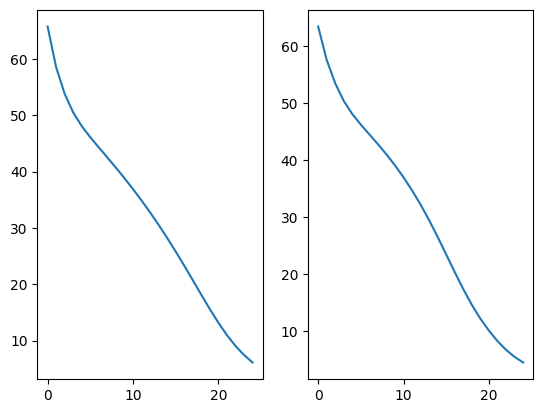

In [61]:
### TODO: 2.3 Initialize and train the RNN Classification Model for X epochs + Evaluation

# Training parameters
SEED = 666
EPOCHS = 25
BATCH_SIZE = 16

LEARNING_RATE = 0.0001

DEVICE = "cpu" # 'cpu', 'mps' or 'cuda'
LABEL_COL = "label"
PAD_IDX = word2idx["<pad>"]
NO_DIPLOM = 1

### YOUR CODE HERE
torch.manual_seed(SEED)
random.seed(SEED)

def plot_metrics(preds_attn, preds_noattn, targets):
    f1_attn = sklearn_metrics.f1_score(targets, preds_attn)
    f1_noattn = sklearn_metrics.f1_score(targets, preds_noattn)

    prec_attn = sklearn_metrics.precision_score(targets, preds_attn)
    prec_noattn = sklearn_metrics.precision_score(targets, preds_noattn)

    recall_attn = sklearn_metrics.recall_score(targets, preds_attn)
    recall_noattn = sklearn_metrics.recall_score(targets, preds_noattn)

    print(f"Model    | With Attention  | No Attention   ")
    print(f"---------|-----------------|----------------")
    print(f"F1 Score | {f1_attn:.2f}            | {f1_noattn:.2f}           ")
    print(f"Precision| {prec_attn:.2f}            | {prec_noattn:.2f}           ")
    print(f"Recall   | {recall_attn:.2f}            | {recall_noattn:.2f}           ")

### Notice: Data loading example
data_samples = dataframe.tokenized
data_labels = dataframe[LABEL_COL].values

X_train, X_test, y_train, y_test = train_test_split(data_samples, data_labels, test_size=0.25, random_state=True)

train_dataset = ThesisClassificationDataset(X_train, y_train, word2idx=word2idx)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, collate_fn=SequencePadder(PAD_IDX))
val_dataset = ThesisClassificationDataset(X_test, y_test, word2idx=word2idx)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, collate_fn=SequencePadder(PAD_IDX))

model = GRU_Classifier(num_embeddings=vocab_size,
                       embedding_dim=300,
                       hidden_dim=64,
                       num_classes=len(LABEL2IDX.keys())-NO_DIPLOM)

model_attn = GRU_Classifier(num_embeddings=vocab_size,
                            embedding_dim=300,
                            hidden_dim=64,
                            num_classes=len(LABEL2IDX.keys())-NO_DIPLOM,
                            with_attention=True)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
optimizer_attn = optim.Adam(model_attn.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

train_losses_attn = []
train_losses_noattn = []

for e in tqdm.tqdm(range(1, EPOCHS+1)):
    train_loss_attn = train(model_attn, train_dataloader, criterion, optimizer_attn, DEVICE)
    train_loss_noattn = train(model, train_dataloader, criterion, optimizer, DEVICE)

    print(train_loss_attn)
    print(train_loss_noattn)

    train_losses_attn.append(train_loss_attn)
    train_losses_noattn.append(train_loss_noattn)

fig = plt.figure(figsize=(12,8))
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(train_losses_attn)
ax2.plot(train_losses_noattn)

eval_loss_attn, preds_attn, attn_dict = eval(model_attn, val_dataloader, criterion, DEVICE, True)
eval_loss_noattn, preds_noattn, _ = eval(model, val_dataloader, criterion, DEVICE, False)

plot_metrics(preds_attn, preds_noattn, y_test)
### END YOUR CODE

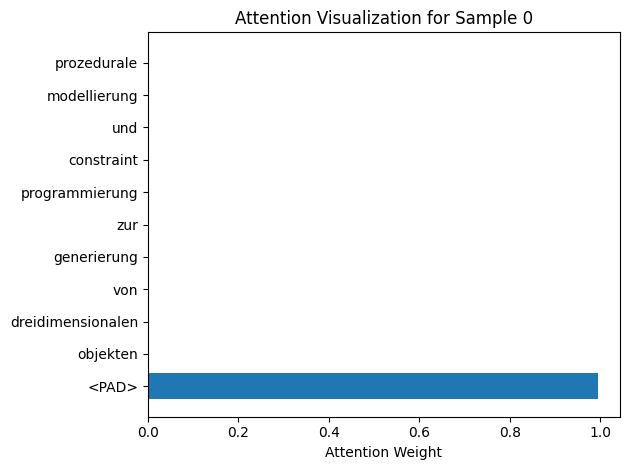

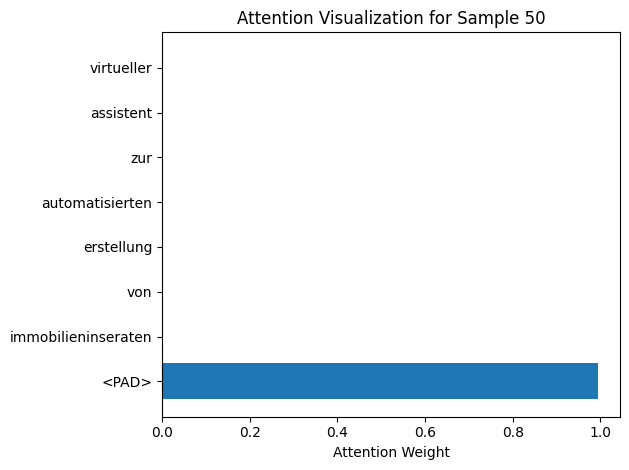

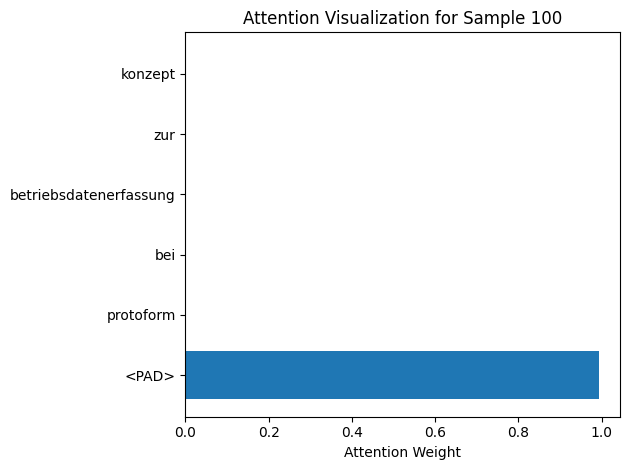

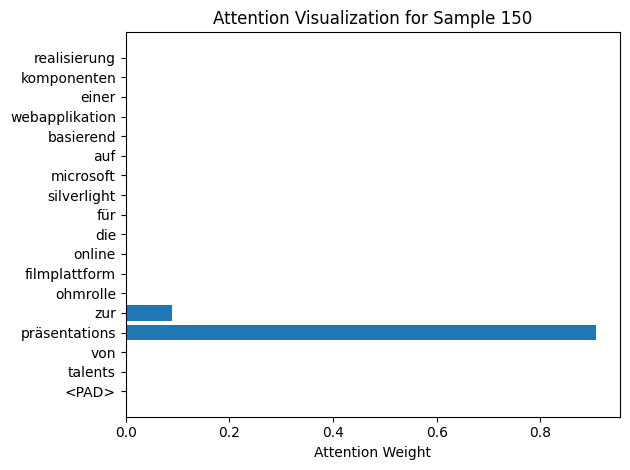

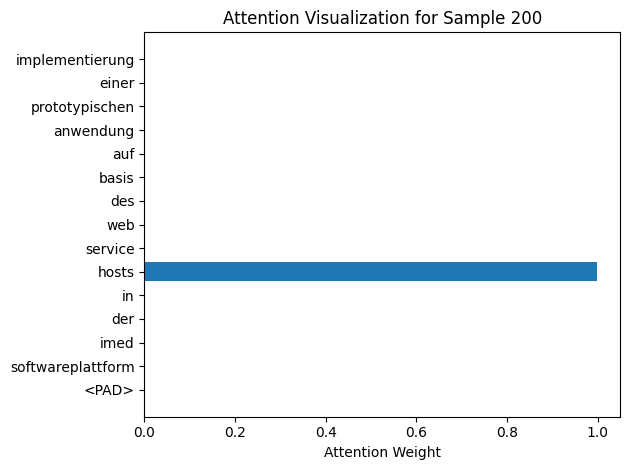

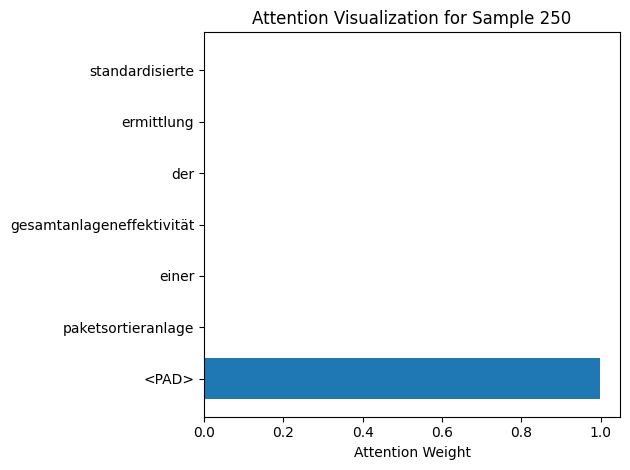

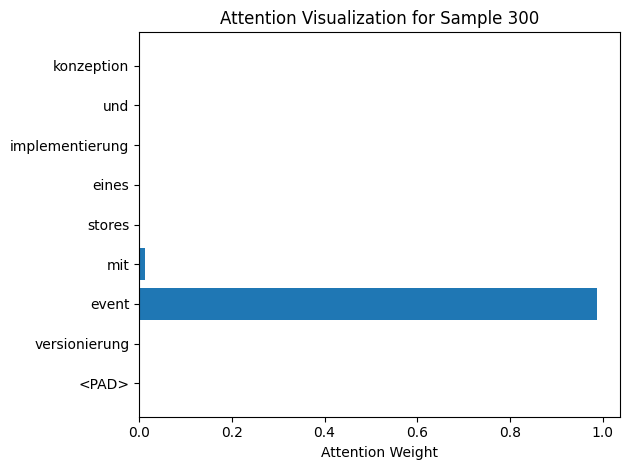

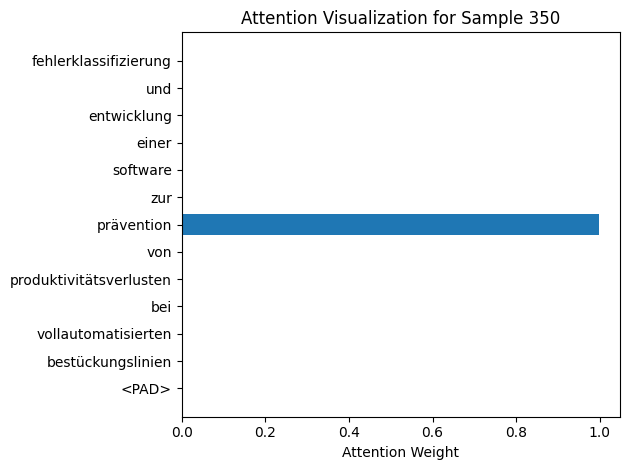

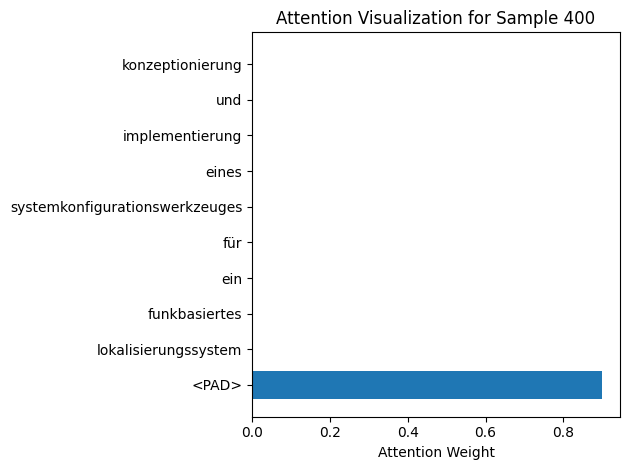

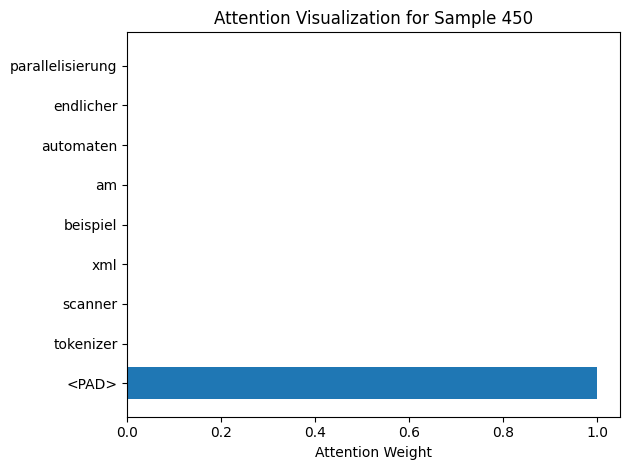

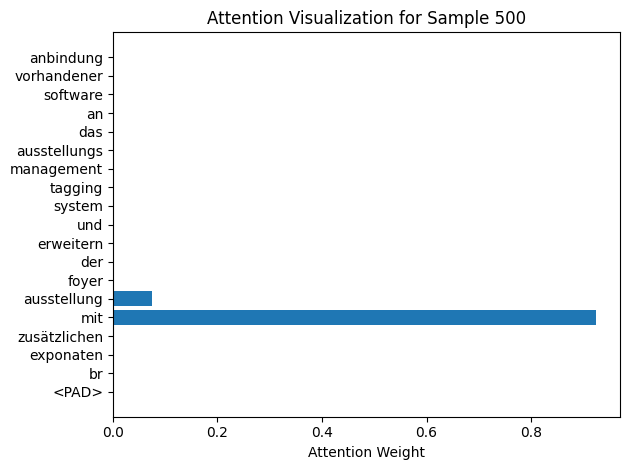

In [ ]:
### TODO: 2.4 Visualize the attention weights

### YOUR CODE HERE

for i in range(0, len(X_test), 50):
    plt.figure()
    
    weights = [weight[0] for weight in attn_dict[i]]
    tokens = X_test.iloc[i]
    
    padded_tokens = tokens + ["<PAD>"] * (len(weights) - len(tokens))
    plt.barh(padded_tokens[::-1], weights[::-1])
    plt.xlabel("Attention Weight")
    plt.title(f"Attention Visualization for Sample {i}")
    plt.tight_layout()
    plt.show()

# i dont know where my error is, i also masked the padding tokens, but they still get attended to

### END YOUR CODE